# Debugging singing extraction pipeline

In [1]:
# Before starting, set the right working dir and imports
import os
if 'path_to_dir' not in globals():
    path_to_dir = os.path.split(os.getcwd())[0]
os.chdir(path_to_dir)

# imports
import numpy as np
import shutil
import matplotlib.pyplot as plt
%matplotlib inline

from sing4me import singing_extract as sing
from sing_experiments import melodies, params

In [2]:
# Global parameters
config = params.singing_2intervals
print(config["reference_mode"])
# Indicate your gender
GENDER = "male" # or "female"


pitch_mode


## Analyse

In [3]:
# import recordings
# recording_file='KeyError_Analysis1.wav'
# recording_file='audio_demo_debug.wav'
recording_file='6c6d1c30-6658-40f7-8e31-5e83591864ea.wav'
#recording_file='c1ca3c5e-6220-494e-8067-03818e097d81.wav'

plot_file_name = f"plot_{recording_file}.png"

target_pitches = [50, 54, 57, 53, 52]
reference_pitch = 50

In [4]:
# analyse
import tempfile
import parselmouth

def recode_wav(file_path):
    with tempfile.NamedTemporaryFile() as temp_file:
        shutil.copyfile(file_path, temp_file.name)
        s = parselmouth.Sound(temp_file.name)
        s.save(file_path, "WAV")

recode_wav(os.path.join("input/", recording_file))

In [5]:
print(target_pitches)

[50, 54, 57, 53, 52]


In [6]:
# compute sung pitches and intervals5
raw = sing.analyze(
    os.path.join("input/",recording_file),
    config,
    target_pitches=target_pitches,
    plot_options=sing.PlotOptions(
        save=True,
        path= os.path.join("output", plot_file_name),
        format="png"
    ),
)

raw = [{key: melodies.as_native_type(value) for key, value in x.items()} for x in raw]
sung_pitches = [x["median_f0"] for x in raw]
sung_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
            sung_pitches,
             "previous_note"
        )

target_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
    target_pitches,
    "previous_note"
)
pitch_heights = melodies.convert_absolute_pitches_to_pitch_heights(
    sung_pitches,
    reference_pitch
)
stats = sing.compute_stats(
    sung_pitches,
    target_pitches,
    sung_intervals,
    target_intervals
)
print(f"sung pitches: {sung_pitches}")
print(f"target pitches: {target_pitches}")
print(f"sung intervals: {sung_intervals}")
print(f"target intervals: {target_intervals}")
print(f"pitch heights: {pitch_heights}")


print(f"stats: {stats}")

selected$("Sound")Plot saved
sung pitches: [49.943731861218396, 55.01299034752705, 50.28821832401874]
target pitches: [50, 54, 57, 53, 52]
sung intervals: [5.069258486308655, -4.724772023508308]
target intervals: [4, 3, -4, -1]
pitch heights: [0.05626813878160419, 5.012990347527051, 0.28821832401874303]
stats: {'num_sung_pitches': 3, 'num_target_pitches': 5, 'raw_pitch_diffs': [-0.05626813878160419, 1.012990347527051, -6.711781675981257], 'mean_pitch_diffs': -1.91835315574527, 'max_abs_pitch_error': 6.711781675981257, 'root_mean_squared_pitch': 3.919069992301009, 'raw_interval_diffs': [1.0692584863086552, -7.724772023508308], 'mean_interval_diff': -3.3277567685998264, 'max_abs_interval_error': 7.724772023508308, 'root_mean_squared_interval': 5.514318476734895, 'direction_accuracy': 25.0}


In [7]:
# extract onsets

MIN_NOTE_DURATION = 0.25

silence_durations, note_durations, ISIs = sing.extract_onsets(raw, MIN_NOTE_DURATION)
print(f"note_durations: {note_durations}")
print(f"silence_durations: {silence_durations}")
print(f"ISIs: {ISIs}")


note_durations: [0.40052154195011325, 0.4679138321995463, 0.4967573696145123]
silence_durations: [0.3843310657596373, 0.45956916099773254, 0.5]
ISIs: [0.7848526077097506, 0.9274829931972788]


In [8]:
is_failed = melodies.failing_criteria(
    sung_intervals,
    sung_pitches,
    reference_pitch,
    config["num_int"],
    config["max_interval_size"],
    config["max_melody_pitch_range"],
    config["reference_mode"],
    stats,
    config["max_abs_interval_error_treshold"],
    config["max_pitch_height"]
)
print(f"Failing Criteria: {is_failed}")

Failing Criteria: {'failed': True, 'reason': 'Wrong number of sung notes: 3  sung out of 5 notes in melody'}


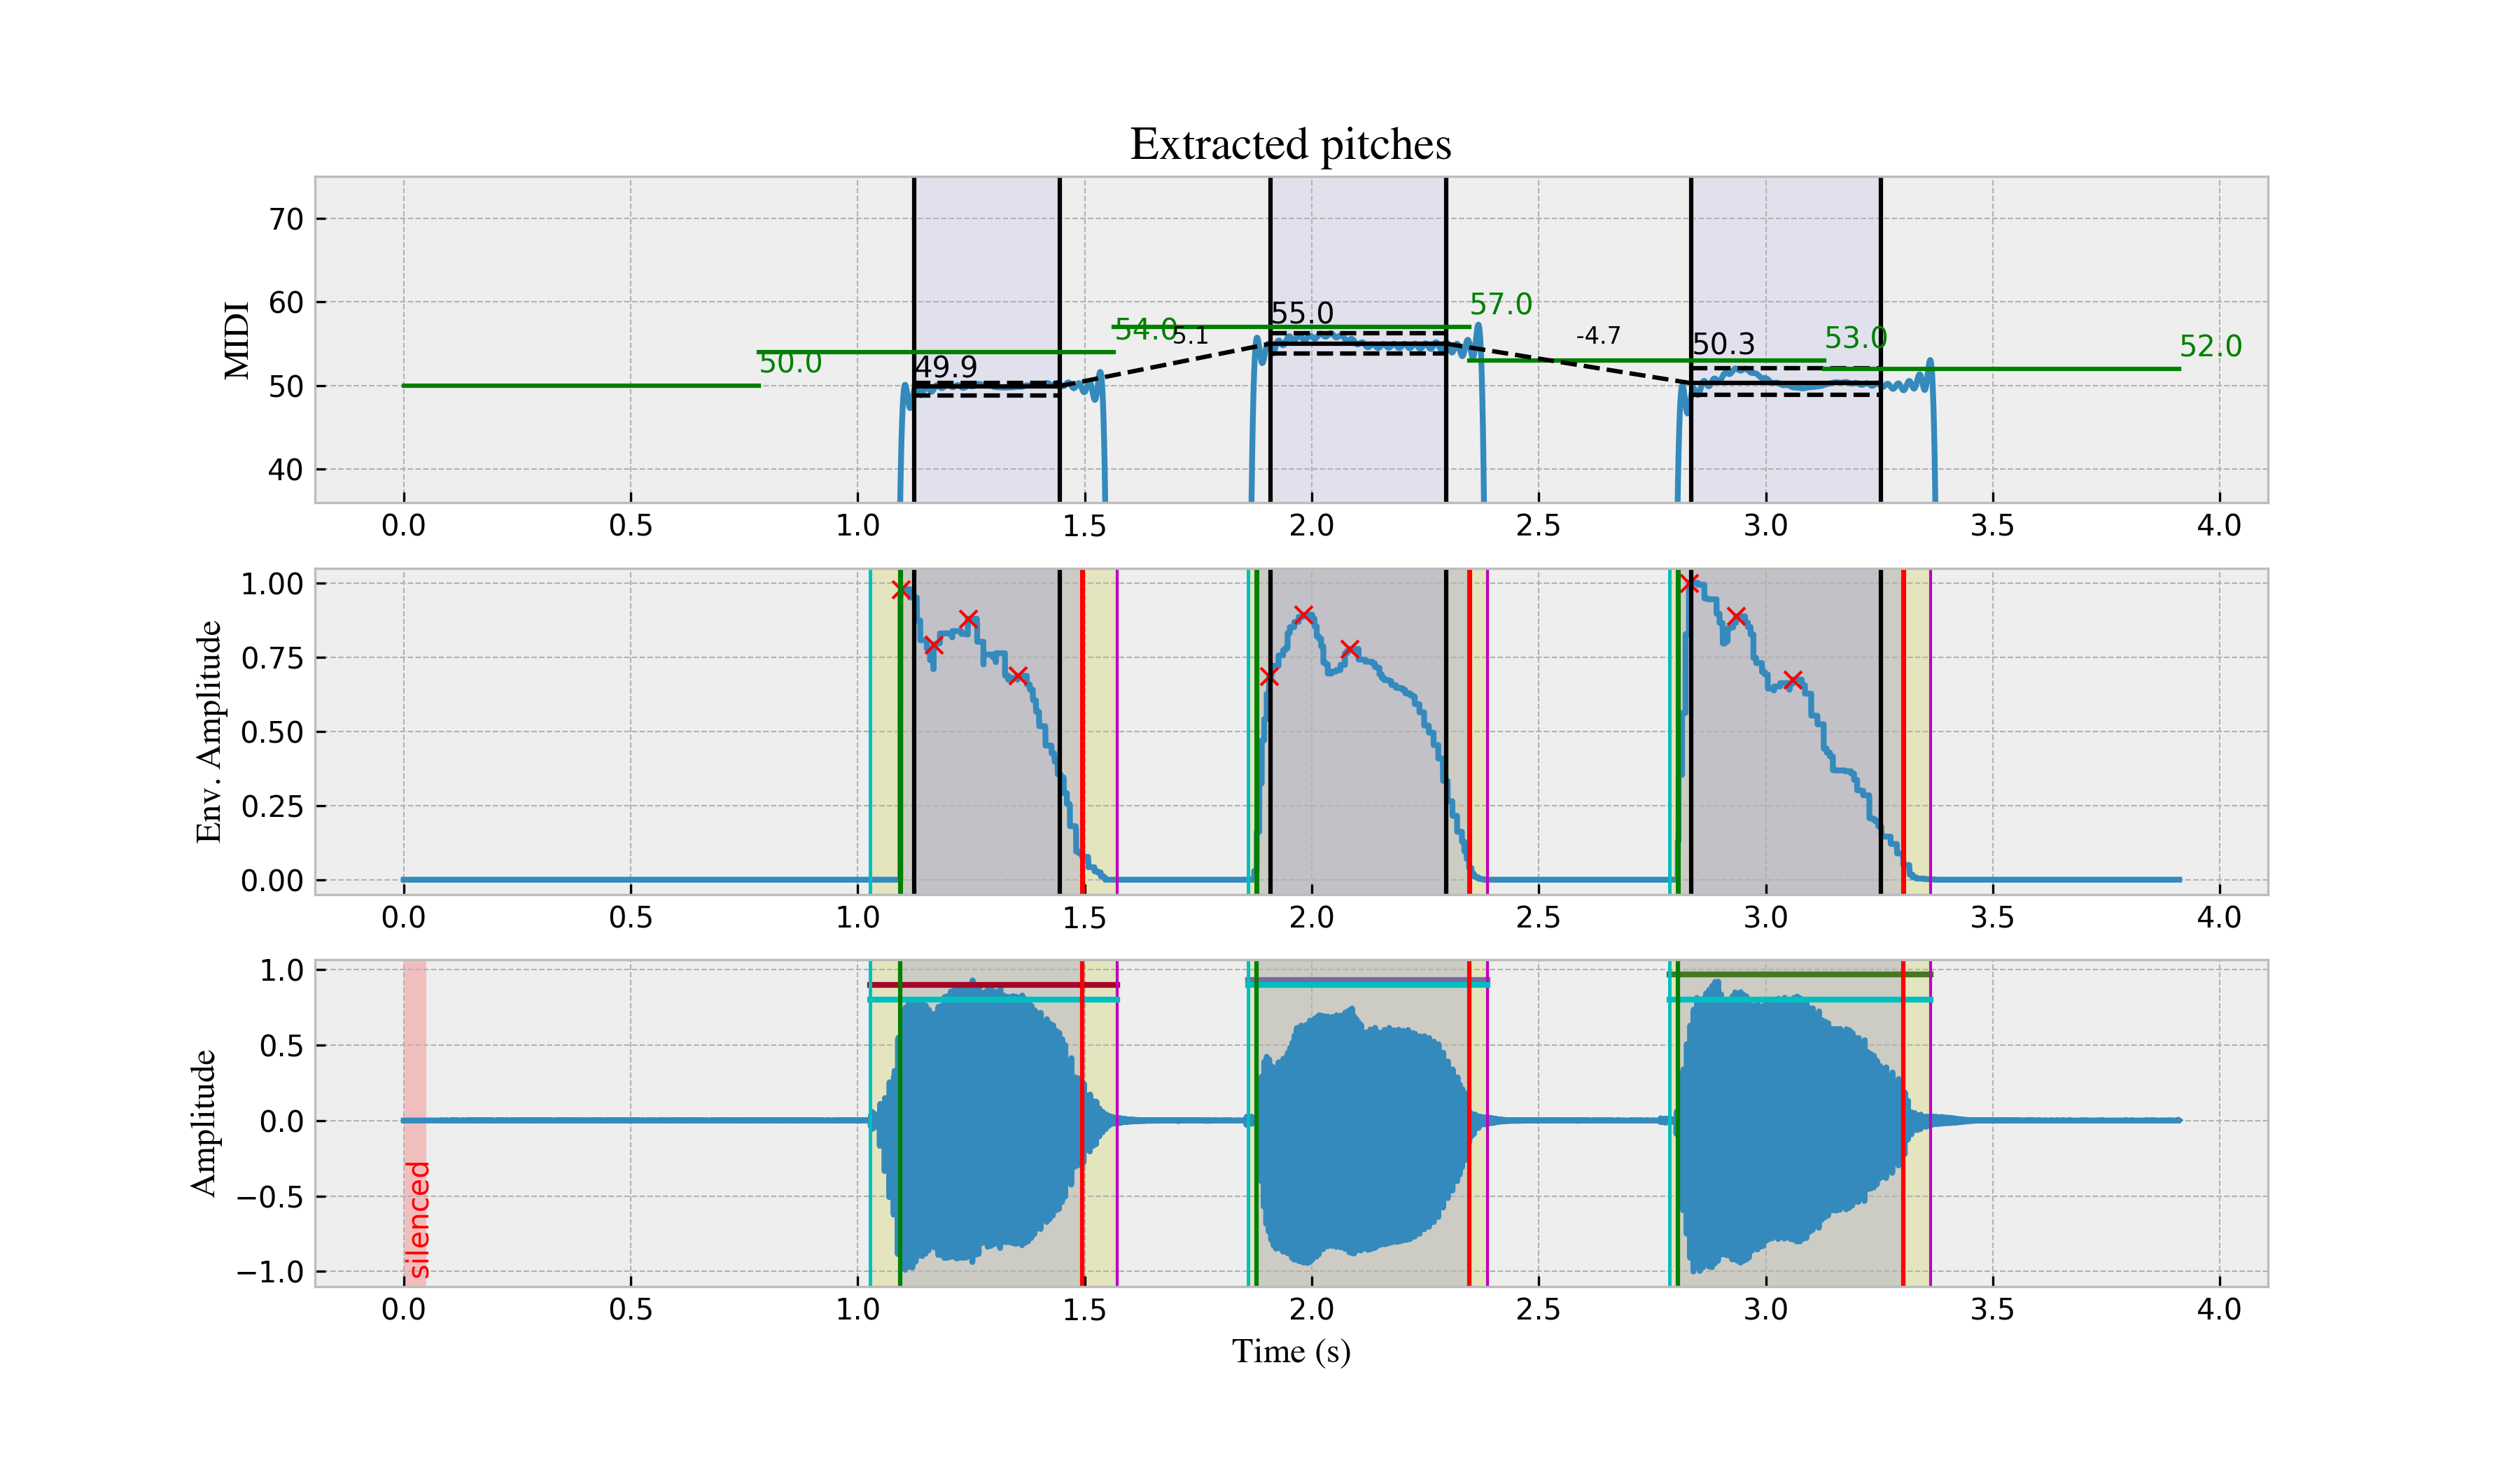

In [9]:
from IPython import display
display.Image(os.path.join("output", plot_file_name))